# Lab 3: Image Manipulations using OpenCV

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs('images', exist_ok=True)

def show(imgs, titles, cmap=None, cols=3):
    rows = int(np.ceil(len(imgs) / cols))
    plt.figure(figsize=(5 * cols, 4.5 * rows))
    for i, (im, t) in enumerate(zip(imgs, titles)):
        plt.subplot(rows, cols, i + 1)
        if im.ndim == 3:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(im, cmap='gray', vmin=0, vmax=255)
        plt.title(f'{t}  {im.shape[1]}x{im.shape[0]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## Step 1: Read an image

<class 'numpy.ndarray'> uint8 (480, 512, 3)


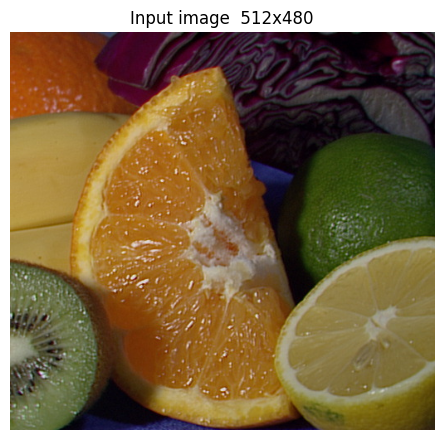

In [2]:
img = cv2.imread('./images/input.jpg')
print(type(img), img.dtype, img.shape)
show([img], ['Input image'], cols=1)

## Step 2: Load an image in grayscale

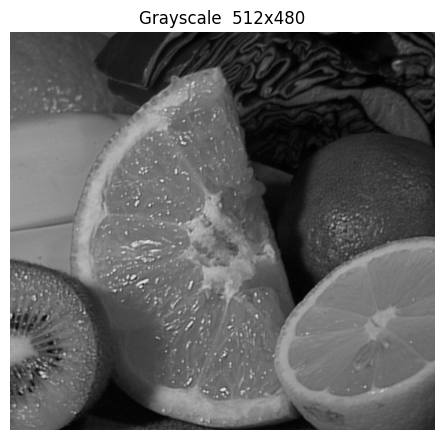

In [3]:
gray_img = cv2.imread('images/input.jpg', cv2.IMREAD_GRAYSCALE)
show([gray_img], ['Grayscale'], cols=1)

## Step 3: Save an image

In [4]:
cv2.imwrite('images/output.jpg', gray_img)

True

## Step 4: Convert to different color spaces

In [5]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
flags = [x for x in dir(cv2) if x.startswith('COLOR_')]
print(len(flags))
print(flags[:20])

374
['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR', 'COLOR_BAYER_BGGR2BGRA', 'COLOR_BAYER_BGGR2BGR_EA', 'COLOR_BAYER_BGGR2BGR_VNG', 'COLOR_BAYER_BGGR2GRAY', 'COLOR_BAYER_BGGR2RGB', 'COLOR_BAYER_BGGR2RGBA', 'COLOR_BAYER_BGGR2RGB_EA', 'COLOR_BAYER_BGGR2RGB_VNG', 'COLOR_BAYER_GB2BGR', 'COLOR_BAYER_GB2BGRA']


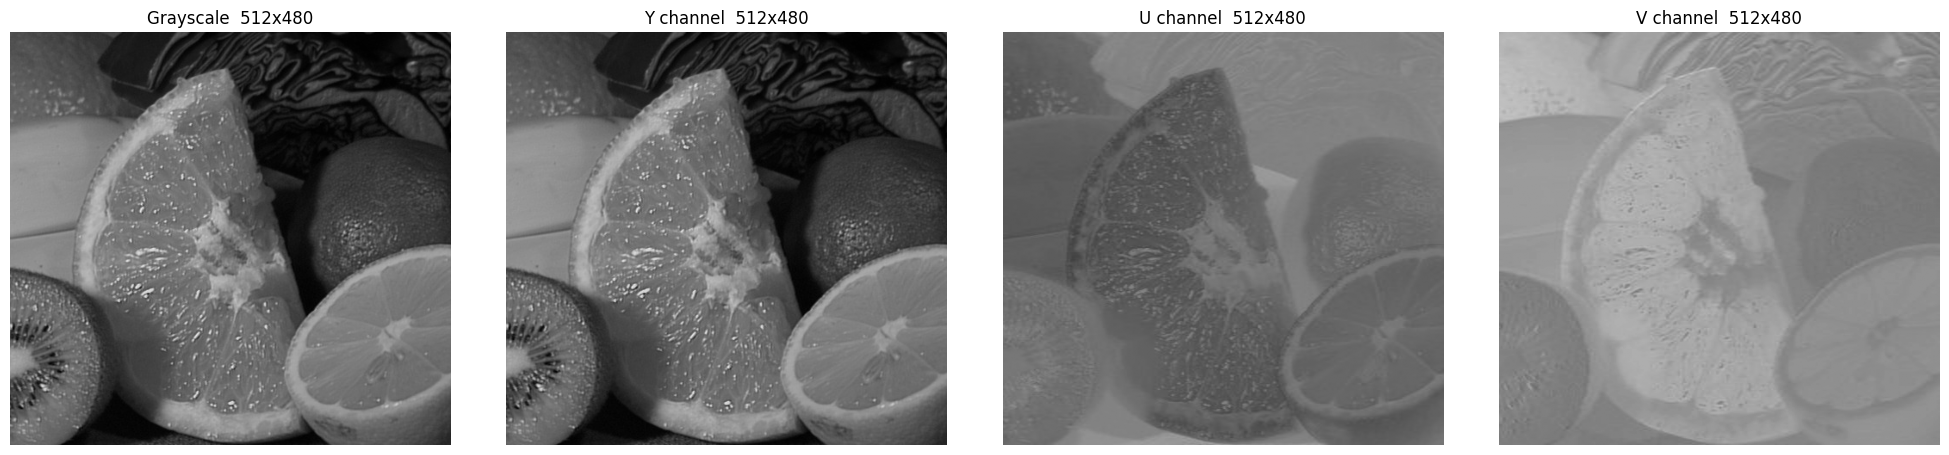

In [6]:
yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
show([gray_img, yuv_img[:, :, 0], yuv_img[:, :, 1], yuv_img[:, :, 2]],
     ['Grayscale', 'Y channel', 'U channel', 'V channel'], cols=4)

## Task 1: Geometric Transformations

### 1. Increase the size of the image

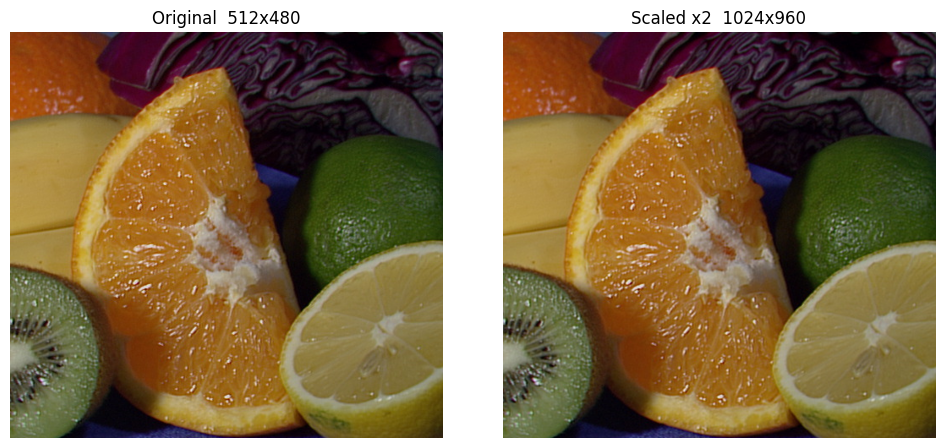

In [7]:
h, w = img.shape[:2]
scaled = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
cv2.imwrite('images/task1_scaled.jpg', scaled)
show([img, scaled], ['Original', 'Scaled x2'], cols=2)

### 2. Rotate the image by 120 degrees

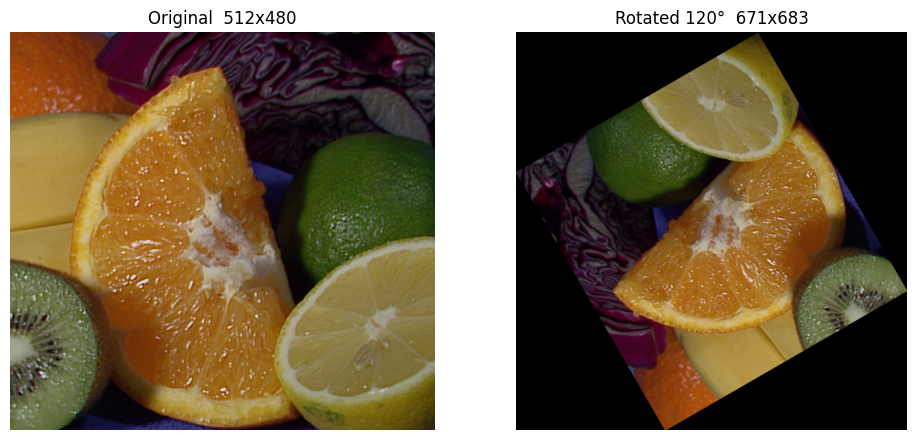

In [8]:
center = (w / 2, h / 2)
M = cv2.getRotationMatrix2D(center, 120, 1.0)
cos, sin = abs(M[0, 0]), abs(M[0, 1])
new_w = int(h * sin + w * cos)
new_h = int(h * cos + w * sin)
M[0, 2] += new_w / 2 - center[0]
M[1, 2] += new_h / 2 - center[1]
rotated = cv2.warpAffine(img, M, (new_w, new_h))
cv2.imwrite('images/task1_rotated_120.jpg', rotated)
show([img, rotated], ['Original', 'Rotated 120°'], cols=2)

### 3. Shear operations

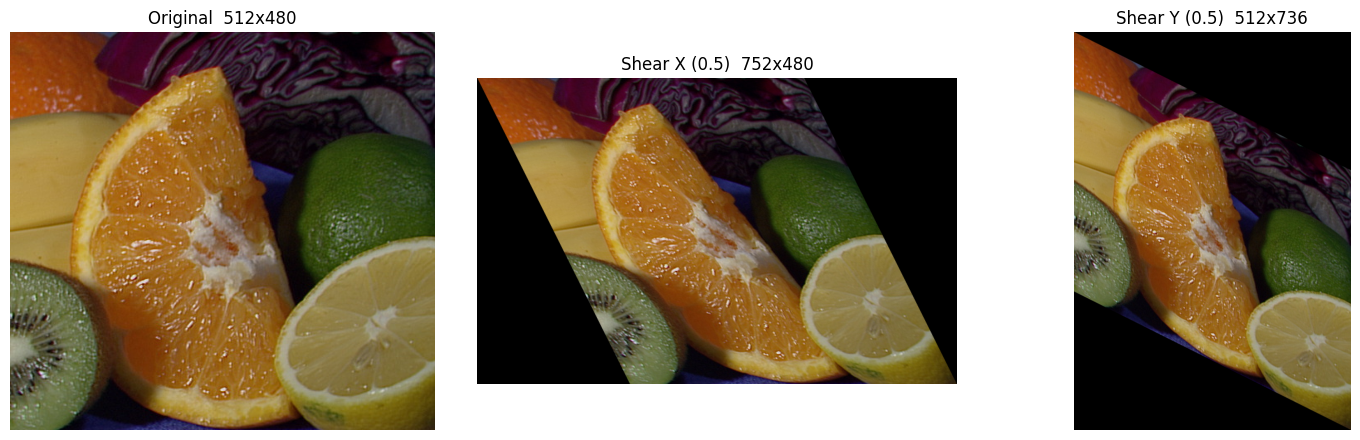

In [9]:
shx, shy = 0.5, 0.5

M_x = np.float32([[1, shx, 0], [0, 1, 0]])
sheared_x = cv2.warpAffine(img, M_x, (int(w + shx * h), h))

M_y = np.float32([[1, 0, 0], [shy, 1, 0]])
sheared_y = cv2.warpAffine(img, M_y, (w, int(h + shy * w)))

cv2.imwrite('images/task1_shear_x.jpg', sheared_x)
cv2.imwrite('images/task1_shear_y.jpg', sheared_y)
show([img, sheared_x, sheared_y], ['Original', 'Shear X (0.5)', 'Shear Y (0.5)'], cols=3)

## Task 2: Intensity Transformations

In [10]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

### 1. Negative image

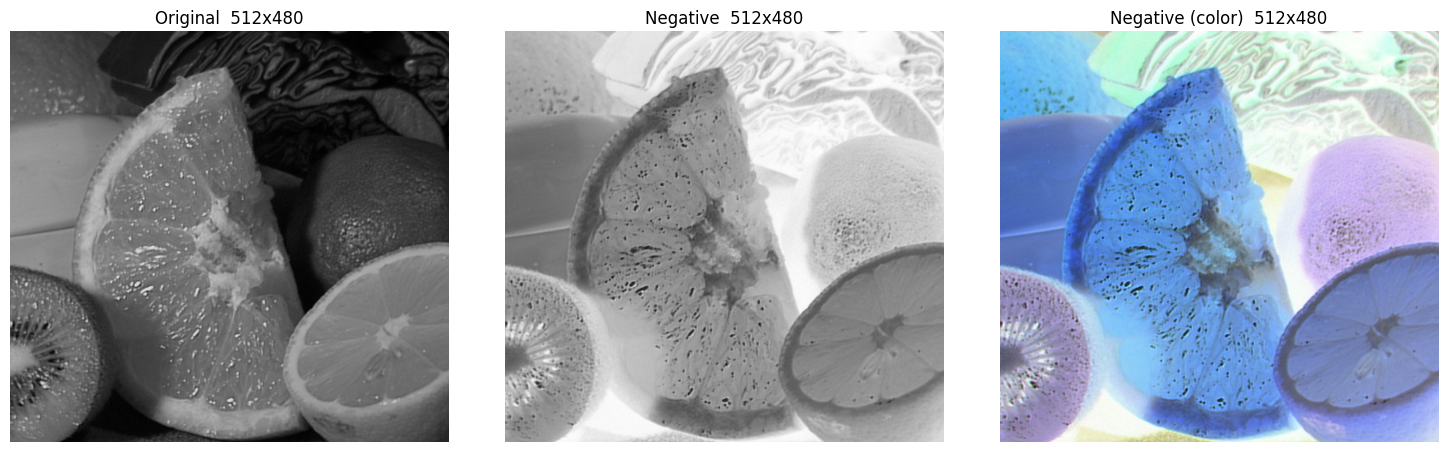

In [11]:
negative = 255 - gray
negative_color = 255 - img
cv2.imwrite('images/task2_negative.jpg', negative)
cv2.imwrite('images/task2_negative_color.jpg', negative_color)
show([gray, negative, negative_color], ['Original', 'Negative', 'Negative (color)'], cols=3)

### 2. Log transformation

c = 46.56


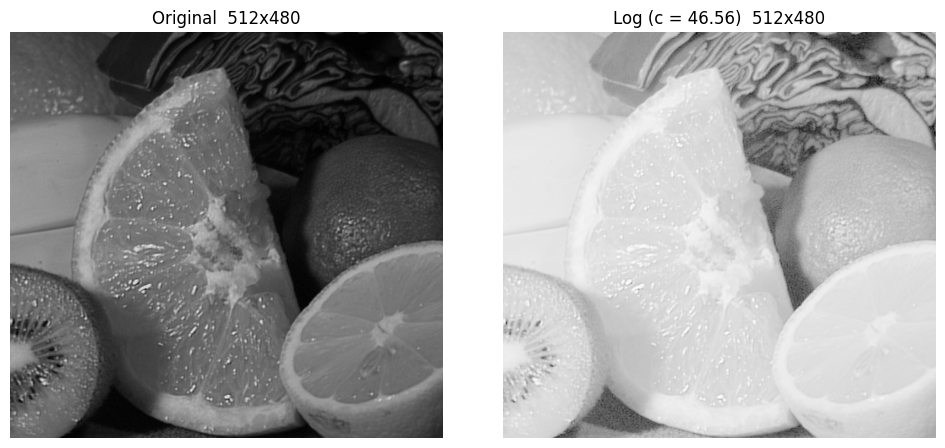

In [12]:
c = 255 / np.log(1 + np.max(gray))
print('c =', c)
log_img = c * np.log(1 + gray.astype(np.float64))
log_img = np.uint8(np.clip(log_img, 0, 255))
cv2.imwrite('images/task2_log.jpg', log_img)
show([gray, log_img], ['Original', f'Log (c = {c:.2f})'], cols=2)

### 3. Power law (gamma) transformation

Std (contrast) original: 45.76 | gamma 0.7 : 47.7


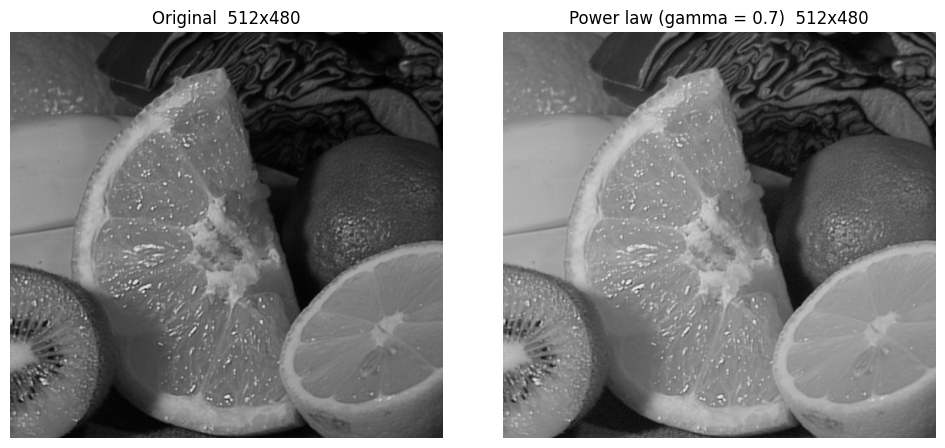

In [13]:
gamma = 0.7
power = 255 * (gray / 255.0) ** gamma
power = np.uint8(np.clip(power, 0, 255))
cv2.imwrite('images/task2_power_gamma.jpg', power)
print('Std (contrast) original:', gray.std().round(2), '| gamma', gamma, ':', power.std().round(2))
show([gray, power], ['Original', f'Power law (gamma = {gamma})'], cols=2)

gamma=0.4: std=42.96
gamma=0.7: std=47.70
gamma=1.0: std=45.76
gamma=1.5: std=38.64
gamma=2.0: std=31.27


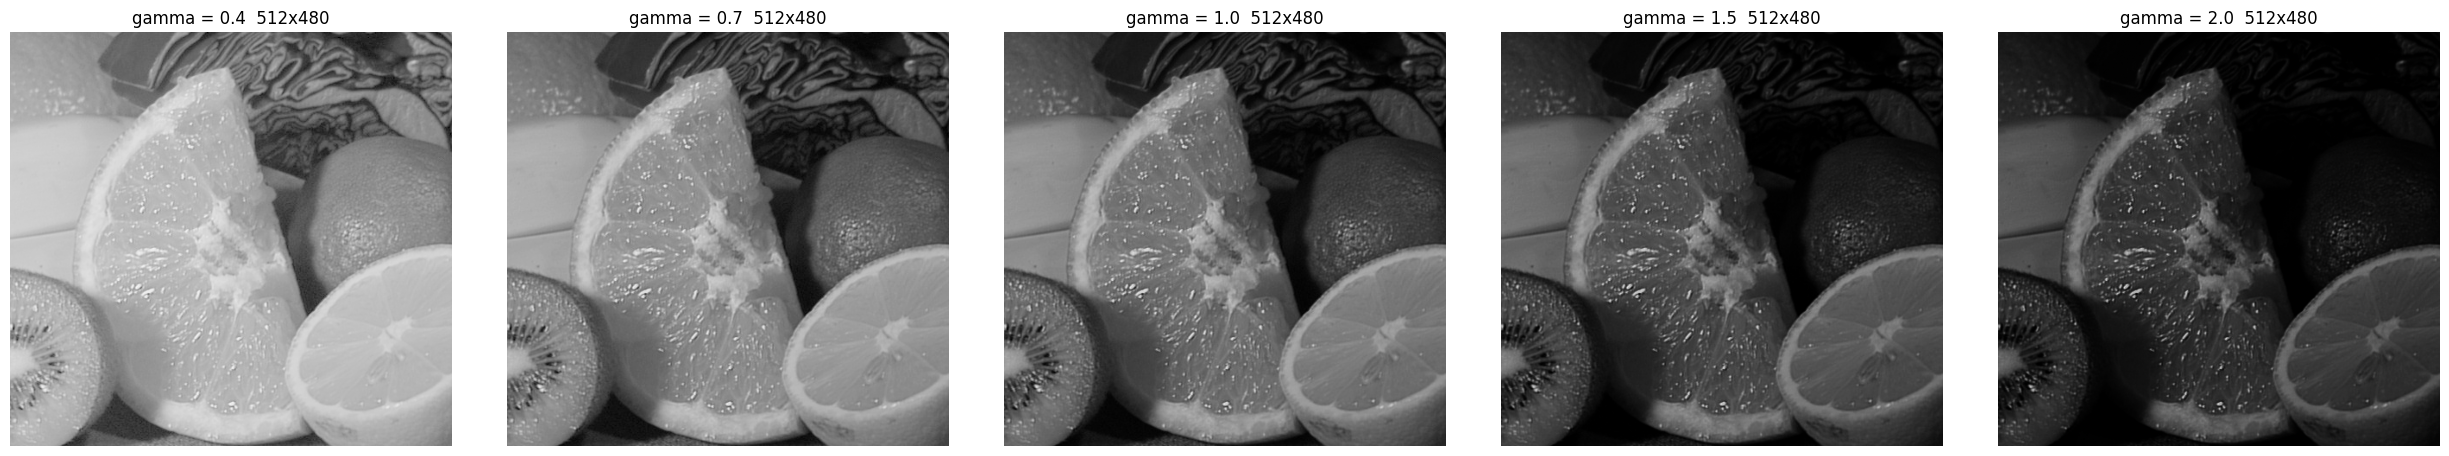

In [14]:
gammas = [0.4, 0.7, 1.0, 1.5, 2.0]
outs = [np.uint8(255 * (gray / 255.0) ** g) for g in gammas]
for g, o in zip(gammas, outs):
    print(f'gamma={g}: std={o.std():.2f}')
show(outs, [f'gamma = {g}' for g in gammas], cols=5)